In [1]:
import glob
import multiprocessing
import os
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from matplotlib.patches import Patch
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm

# Esfahani Biological Validation
Correlate cfDNA fragmentation features with gene expression (TPM) from Esfahani et al.

In [2]:
def sync_file_lists(list1, list2):
    """Match each ID in list1 to the best file in list2 by longest common substring."""
    if not list2:
        return [None] * len(list1)
    synced = []
    for path1 in list1:
        s1 = str(path1)
        best, best_size = None, -1
        for path2 in list2:
            m = SequenceMatcher(a=s1, b=str(path2), autojunk=False).find_longest_match()
            if m.size > best_size:
                best_size = m.size
                best = path2
        synced.append(best)
    return synced


def _worker_load_feature(file_path, feature_name):
    try:
        df = pd.read_csv(file_path, usecols=[feature_name])
        return df[feature_name].values
    except Exception as e:
        print(f"Error loading {os.path.basename(str(file_path))}: {e}")
        return None


def load_feature_in_parallel(folder_path, feature_name, file_filter=None, n_jobs=None):
    """Load a single feature column from all BIN.csv files in parallel."""
    all_files = sorted(glob.glob(os.path.join(folder_path, "*_BIN.csv")))
    if not all_files:
        return None
    if file_filter:
        all_files = sync_file_lists(file_filter, [Path(f) for f in all_files])
    if n_jobs is None:
        n_jobs = min(multiprocessing.cpu_count(), 4)
    results = Parallel(n_jobs=n_jobs)(
        delayed(_worker_load_feature)(f, feature_name) for f in all_files
    )
    valid = [r for r in results if r is not None]
    if not valid:
        return None
    return np.stack(valid, axis=0)

In [3]:
# --- Configuration ---
FEATURES_DIR = "./extracted_features/biomart_10kb"
TSS_FEATURES = ['fslr', 'fslr_coverage', 'griffin_diff', 'rcov', 'mwh']

FEATURE_COLORS = {
    'fslr': (46/255, 37/255, 133/255),
    'fslr_coverage': (51/255, 117/255, 56/255),
    'griffin_diff': (93/255, 168/255, 153/255),
    'rcov': (220/255, 205/255, 125/255),
    'mwh': (159/255, 74/255, 150/255),
}
FEATURE_NAMES = {
    'fslr': 'FSLR', 'fslr_coverage': 'FSLRC',
    'griffin_diff': 'GD', 'rcov': 'RCOV', 'mwh': 'MWH',
}

# Aliases used by the bar plot cell
feature_colors = FEATURE_COLORS
feature_names = FEATURE_NAMES

# --- Load metadata (PoN = first 50 healthy) ---
cris_metadata = pd.read_csv("accessory_files/cris_metadata.csv")
healthy_file_names = cris_metadata[cris_metadata["disease"] == "Healthy"].iloc[:50]["ID"].tolist()

print(f"PoN healthy samples: {len(healthy_file_names)}")

PoN healthy samples: 50


## 1. Load feature arrays

In [4]:
# Load all features for PoN healthy samples with progress tracking
feature_arrays_healthy = {}

print(f"Loading {len(TSS_FEATURES)} features for {len(healthy_file_names)} PoN samples...")
for i, feat in enumerate(TSS_FEATURES, 1):
    print(f"  [{i}/{len(TSS_FEATURES)}] Loading '{feat}'...", end=" ", flush=True)
    feature_arrays_healthy[feat] = load_feature_in_parallel(
        FEATURES_DIR, feat, file_filter=healthy_file_names)
    print(f"shape {feature_arrays_healthy[feat].shape}")

print("All features loaded.")

Loading 5 features for 50 PoN samples...
  [1/5] Loading 'fslr'... shape (50, 19376)
  [2/5] Loading 'fslr_coverage'... 

KeyboardInterrupt: 

## 2. Esfahani gene groups & QC blacklist

In [ ]:
esf = pd.read_excel(
    'accessory_files/esfahani_supplement.xlsx',
    sheet_name='Supplementary Table 2', header=6,
    usecols=['Gene group', 'TPM [log2]'],
)
biomart = pd.read_csv(
    "beds/biomart_10kb.bed", sep="\t",
    names=["chrom", "start", "end", "gene_name", "strand", "GC"],
)
to_filter = np.load("accessory_files/final_tss_indices_to_remove_hg38.npy")
biomart_genes_filtered = set(biomart.iloc[to_filter]['gene_name'].values)

print(f"Esfahani gene groups: {len(esf)}")
print(f"Biomart TSS regions: {len(biomart)}")
print(f"QC-blacklisted genes: {len(biomart_genes_filtered)}")

## 3. Map gene groups to features

In [ ]:
# Process all gene groups: track filtered genes per group,
# compute feature means for healthy cohort

features_to_analyze = TSS_FEATURES
all_gene_groups_data = []

for _, row in tqdm(esf.iterrows(), total=len(esf)):
    genes = [g.strip() for g in row['Gene group'].split('|')]
    tpm = row['TPM [log2]']

    all_indices, unfiltered_indices = [], []
    n_filtered = 0
    for gene in genes:
        idx = biomart.index[biomart['gene_name'] == gene].tolist()
        if idx:
            all_indices.extend(idx)
            if gene in biomart_genes_filtered:
                n_filtered += 1
            else:
                unfiltered_indices.extend(idx)

    if not all_indices:
        continue

    group = {
        'tpm': tpm, 'genes_filtered': n_filtered,
        'all_indices': all_indices, 'unfiltered_indices': unfiltered_indices,
        'feat_all_healthy': {}, 'feat_filt_healthy': {},
    }
    for feat in features_to_analyze:
        group['feat_all_healthy'][feat] = np.nanmean(
            feature_arrays_healthy[feat][:, all_indices], axis=1)
        if unfiltered_indices:
            group['feat_filt_healthy'][feat] = np.nanmean(
                feature_arrays_healthy[feat][:, unfiltered_indices], axis=1)
        else:
            group['feat_filt_healthy'][feat] = None

    all_gene_groups_data.append(group)

# Alias for the bar plot cell
tpm_values_per_gene_group = np.array([g['tpm'] for g in all_gene_groups_data])

print(f"Processed {len(all_gene_groups_data)} gene groups")
max_filtered = max(g['genes_filtered'] for g in all_gene_groups_data)
print(f"Max filtered genes in any group: {max_filtered}")
print(f"Distribution: {np.bincount([g['genes_filtered'] for g in all_gene_groups_data])}")

## 4. Correlation vs filtering threshold

In [ ]:
# Sweep thresholds: how does Pearson r change as we allow more filtered genes?
thresholds = list(range(max_filtered + 1))

threshold_results = {
    'threshold': [], 'n_groups': [],
    'feature_correlations': {f: {'mean': [], 'std': [], 'all_corrs': []}
                             for f in features_to_analyze},
}

for threshold in thresholds:
    selected = [g for g in all_gene_groups_data if g['genes_filtered'] <= threshold]
    if not selected:
        continue
    threshold_results['threshold'].append(threshold)
    threshold_results['n_groups'].append(len(selected))

    for feat in features_to_analyze:
        tpm_vals, feat_by_sample = [], [[] for _ in range(feature_arrays_healthy[feat].shape[0])]
        for g in selected:
            if g['feat_filt_healthy'][feat] is not None:
                tpm_vals.append(g['tpm'])
                for si, v in enumerate(g['feat_filt_healthy'][feat]):
                    feat_by_sample[si].append(v)
        tpm_arr = np.array(tpm_vals)

        corrs = []
        for si in range(len(feat_by_sample)):
            fv = np.array(feat_by_sample[si])
            mask = ~(np.isnan(tpm_arr) | np.isnan(fv))
            if mask.sum() >= 3:
                r, _ = pearsonr(tpm_arr[mask], fv[mask])
                corrs.append(r)
        corrs = np.array(corrs)
        threshold_results['feature_correlations'][feat]['mean'].append(np.mean(corrs))
        threshold_results['feature_correlations'][feat]['std'].append(np.std(corrs))
        threshold_results['feature_correlations'][feat]['all_corrs'].append(corrs)

print("Threshold sweep complete")

## 5. Per-sample Pearson correlations

In [ ]:
# Correlations using ALL gene groups (no threshold filtering)
tpm_all = np.array([g['tpm'] for g in all_gene_groups_data])

feature_correlations = {f: {'pearson': [], 'spearman': [], 'pearson_pval': [], 'spearman_pval': []}
                        for f in features_to_analyze}

for feat in features_to_analyze:
    feat_matrix = np.array([g['feat_all_healthy'][feat] for g in all_gene_groups_data])
    for si in range(feat_matrix.shape[1]):
        fv = feat_matrix[:, si]
        mask = ~(np.isnan(tpm_all) | np.isnan(fv))
        if mask.sum() >= 3:
            rp, pp = pearsonr(tpm_all[mask], fv[mask])
            rs, ps = spearmanr(tpm_all[mask], fv[mask])
        else:
            rp, pp, rs, ps = np.nan, np.nan, np.nan, np.nan
        feature_correlations[feat]['pearson'].append(rp)
        feature_correlations[feat]['spearman'].append(rs)
        feature_correlations[feat]['pearson_pval'].append(pp)
        feature_correlations[feat]['spearman_pval'].append(ps)

for feat in features_to_analyze:
    corrs = np.array(feature_correlations[feat]['pearson'])
    valid = corrs[~np.isnan(corrs)]
    print(f"{FEATURE_NAMES[feat]}: Pearson r = {np.mean(valid):.3f} ± {np.std(valid):.3f}")

## 6. Horizontal bar plot — Pearson correlations

/tmp/ipykernel_10792/2925524796.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{tick:.1f}' for tick in ax.get_xticks()], fontsize=12)


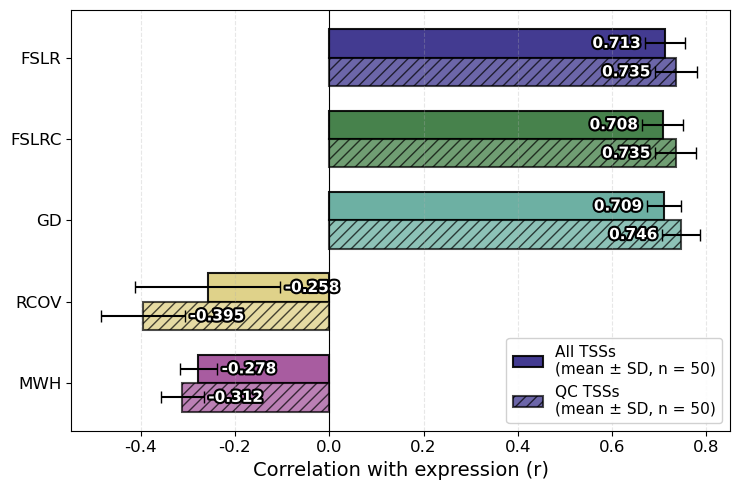


Horizontal bar plot shows mean ± std Pearson correlation across all healthy samples
  - All genes: 1748 gene groups
  - Filtered (≤1 gene filtered/group): 501 gene groups


In [ ]:
# Create horizontal bar plot showing Pearson correlations for healthy samples
# Shows both original (all genes) and filtered (threshold ≤1) results grouped by feature

from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))

# Prepare data for plotting - both original and filtered
original_means = []
original_stds = []
filtered_means = []
filtered_stds = []
colors = []
labels = []

# Get filtered results at threshold ≤1
threshold_idx = 1 if 1 in threshold_results['threshold'] else 0

for feature in features_to_analyze:
    # Original (all genes)
    corrs = np.array(feature_correlations[feature]['pearson'])
    valid_corrs = corrs[~np.isnan(corrs)]
    original_means.append(np.mean(valid_corrs))
    original_stds.append(np.std(valid_corrs))
    
    # Filtered (threshold ≤1)
    filtered_mean = threshold_results['feature_correlations'][feature]['mean'][threshold_idx]
    filtered_std = threshold_results['feature_correlations'][feature]['std'][threshold_idx]
    filtered_means.append(filtered_mean)
    filtered_stds.append(filtered_std)
    
    colors.append(feature_colors[feature])
    labels.append(feature_names[feature])

# Create grouped horizontal bars - more compact spacing
bar_height = 0.35
positions = np.arange(len(features_to_analyze)) * 1.0  # Closer spacing for compact layout

# Original bars (solid)
bars_original = ax.barh(positions - bar_height/2, original_means, bar_height,
                        xerr=original_stds, capsize=4, alpha=0.9, color=colors,
                        error_kw={'linewidth': 1.5, 'ecolor': 'black'},
                        label='All TSSs\n(mean ± SD, n = 50)', edgecolor='black', linewidth=1.5)

# Filtered bars (hatched pattern)
bars_filtered = ax.barh(positions + bar_height/2, filtered_means, bar_height,
                        xerr=filtered_stds, capsize=4, alpha=0.7, color=colors,
                        error_kw={'linewidth': 1.5, 'ecolor': 'black'},
                        label='QC TSSs\n(mean ± SD, n = 50)', 
                        edgecolor='black', linewidth=1.5, hatch='///')

# Customize
ax.set_xlabel('Pearson correlation with expression (r)', fontsize=14)
ax.set_yticks(positions)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xticklabels([f'{tick:.1f}' for tick in ax.get_xticks()], fontsize=12)
ax.grid(True, alpha=0.3, axis='x', linestyle='--')
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.8)

# Add value labels on bars with white outline for better visibility
import matplotlib.patheffects as path_effects

for i, (mean, std, pos) in enumerate(zip(original_means, original_stds, positions)):
    x_pos = mean - std - 0.01 if mean > 0 else mean + std + 0.01
    ha = 'right' if mean > 0 else 'left'
    text = ax.text(x_pos, pos - bar_height/2, f'{mean:.3f}',
                   ha=ha, va='center', fontsize=11, fontweight='bold', color='white')
    # Add white outline
    text.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                          path_effects.Normal()])

for i, (mean, std, pos) in enumerate(zip(filtered_means, filtered_stds, positions)):
    x_pos = mean - std - 0.01 if mean > 0 else mean + std + 0.01
    ha = 'right' if mean > 0 else 'left'
    text = ax.text(x_pos, pos + bar_height/2, f'{mean:.3f}',
                   ha=ha, va='center', fontsize=11, fontweight='bold', color='white')
    # Add white outline
    text.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                          path_effects.Normal()])

# Add legend
ax.legend(fontsize=11, loc='lower right', framealpha=0.9)

# Invert y-axis to have first feature at top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('esfahani_correlation_barplots.png', dpi=300, bbox_inches='tight')
plt.show()

n_groups_filtered = threshold_results['n_groups'][threshold_idx]
print(f"\nHorizontal bar plot shows mean ± std Pearson correlation across all healthy samples")
print(f"  - All genes: {len(tpm_values_per_gene_group)} gene groups")
print(f"  - Filtered (≤1 gene filtered/group): {n_groups_filtered} gene groups")

In [ ]:
ax.get_xticks()

array([-0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ])